# AI-Based Resume Screening and Classification System 

This project uses Natural Language Processing (NLP) and Machine Learning to automatically classify resumes into job categories.

The system analyzes resume text, extracts important information, and predicts the most suitable job domain based on the candidate's skills and experience.

### 1. Import Required Libraries

In [205]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import re
import string
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score,f1_score,confusion_matrix

### 2. Load the Dataset

Resume dataset collected in JSON format.

In [206]:
data= pd.read_json(
    'resumes_dataset.jsonl',
    lines=True
)

### 3. Exploratory Data Analysis(EDA)

In [207]:
data.head()

,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source
0,REAL_0001,Java Developer,Chad Griffin,contact@email.com,94105 555 4321000 10 ...,"City, State",jessica claire montgomery street san francisco...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco...,Computer Science degree,jessica claire montgomery street san francisco...,ResumeAtlas
1,REAL_0002,Java Developer,Melinda Thomas,contact@email.com,17994568777 2017 2018 20152016 3 ...,"City, State",jared arthur maica java developer 17994568777 ...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 ...,Computer Science degree,jared arthur maica java developer 17994568777 ...,ResumeAtlas
2,REAL_0003,Java Developer,Shannon Mccarthy,contact@email.com,9 555 4321000 94105 8 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas
3,REAL_0004,Java Developer,Christine Kelley,contact@email.com,9 555 4321000 94105 5 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas
4,REAL_0005,Java Developer,Karen Holt,contact@email.com,100 10 4321000 ...,"City, State",jessica claire 100 montgomery st 10th floor xx...,"Python, SQL, Git, Linux",jessica claire 100 montgomery st 10th floor xx...,Computer Science degree,jessica claire 100 montgomery st 10th floor xx...,ResumeAtlas


In [208]:
data.shape

(3500, 12)

**Dataset Information**

In [209]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ResumeID    3500 non-null   object
 1   Category    3500 non-null   object
 2   Name        3500 non-null   object
 3   Email       3500 non-null   object
 4   Phone       3500 non-null   object
 5   Location    3500 non-null   object
 6   Summary     3500 non-null   object
 7   Skills      3500 non-null   object
 8   Experience  3500 non-null   object
 9   Education   3500 non-null   object
 10  Text        3500 non-null   object
 11  Source      3500 non-null   object
dtypes: object(12)
memory usage: 328.3+ KB


**Missing Values/Null Values**

In [210]:
data.isnull().sum()

ResumeID      0
Category      0
Name          0
Email         0
Phone         0
Location      0
Summary       0
Skills        0
Experience    0
Education     0
Text          0
Source        0
dtype: int64

**Duplicate Values**

In [211]:
data.duplicated().sum()

0

In [212]:
for i in data.columns:
    print(i , data[i].nunique())

ResumeID 3500
Category 36
Name 3410
Email 1161
Phone 3279
Location 1164
Summary 2226
Skills 919
Experience 3262
Education 1160
Text 3304
Source 2


**Data Cleaning**

In [213]:
df=data.copy()

In [214]:
df.drop(columns=['ResumeID','Name','Email','Location','Source','Phone'],inplace=True)

In [215]:
df.columns=df.columns.str.lower()

In [216]:
df.head()

,category,summary,skills,experience,education,text
0,Java Developer,jessica claire montgomery street san francisco...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco...,Computer Science degree,jessica claire montgomery street san francisco...
1,Java Developer,jared arthur maica java developer 17994568777 ...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 ...,Computer Science degree,jared arthur maica java developer 17994568777 ...
2,Java Developer,jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...
3,Java Developer,jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...
4,Java Developer,jessica claire 100 montgomery st 10th floor xx...,"Python, SQL, Git, Linux",jessica claire 100 montgomery st 10th floor xx...,Computer Science degree,jessica claire 100 montgomery st 10th floor xx...


In [217]:
df['category'].unique()

array(['Java Developer', 'Python Developer', 'Data Science', 'DevOps',
       'SQL Developer', 'Database', 'Testing', 'Web Designing',
       'React Developer', 'DotNet Developer', 'ETL Developer',
       'Network Security Engineer', 'SAP Developer', 'Blockchain',
       'Business Analyst', 'Digital Media', 'Software Developer',
       'Full Stack Developer', 'Cloud Engineer',
       'Machine Learning Engineer', 'Frontend Developer',
       'Backend Developer', 'AI Engineer', 'Cybersecurity Analyst',
       'QA Engineer', 'Database Administrator', 'UI/UX Designer',
       'Site Reliability Engineer', 'Mobile Developer',
       'System Administrator', 'Technical Lead', 'Blockchain Developer',
       'Engineering Manager', 'Principal Engineer', 'Product Manager',
       'Technical Writer'], dtype=object)

**Univariate Analysis**

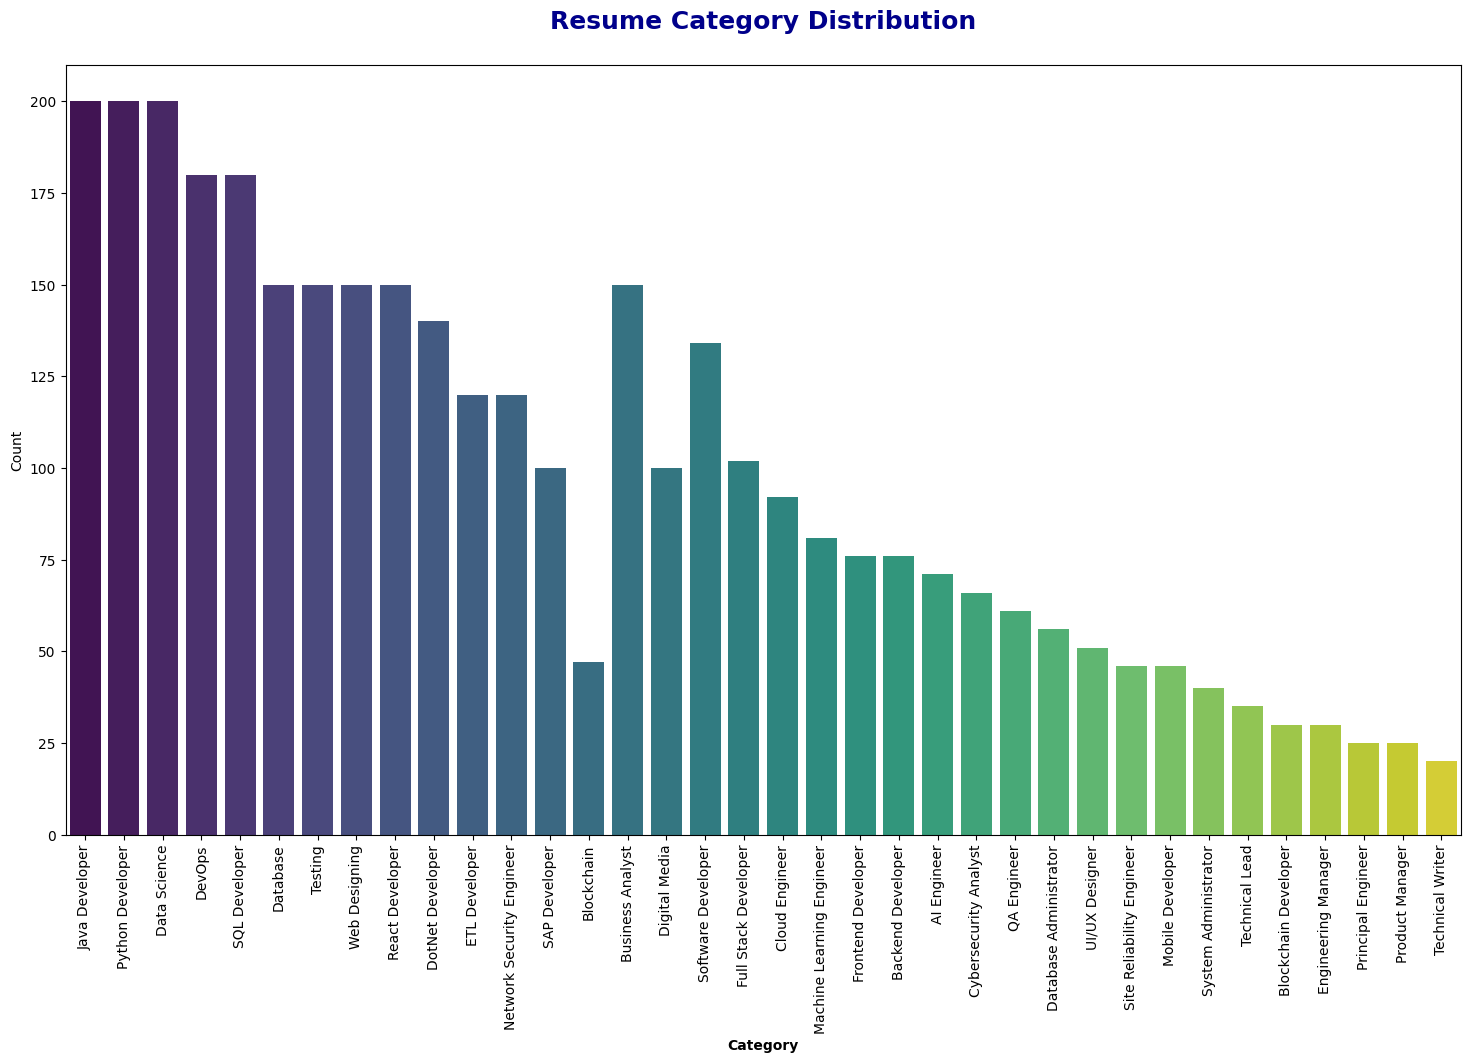

In [218]:
plt.figure(figsize=(18,10))
sns.countplot(data=df,x=df['category'],palette='viridis',hue='category')
plt.title("Resume Category Distribution\n",fontdict={
        'fontsize': 18,
        'fontweight': 'bold',
        'color': 'darkblue'
    })
plt.xlabel("Category",fontdict={'fontweight':'bold'})
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

This visualization shows the number of resumes available for each job category. It helps identify class imbalance issues.

**Pie Chart Distribution**

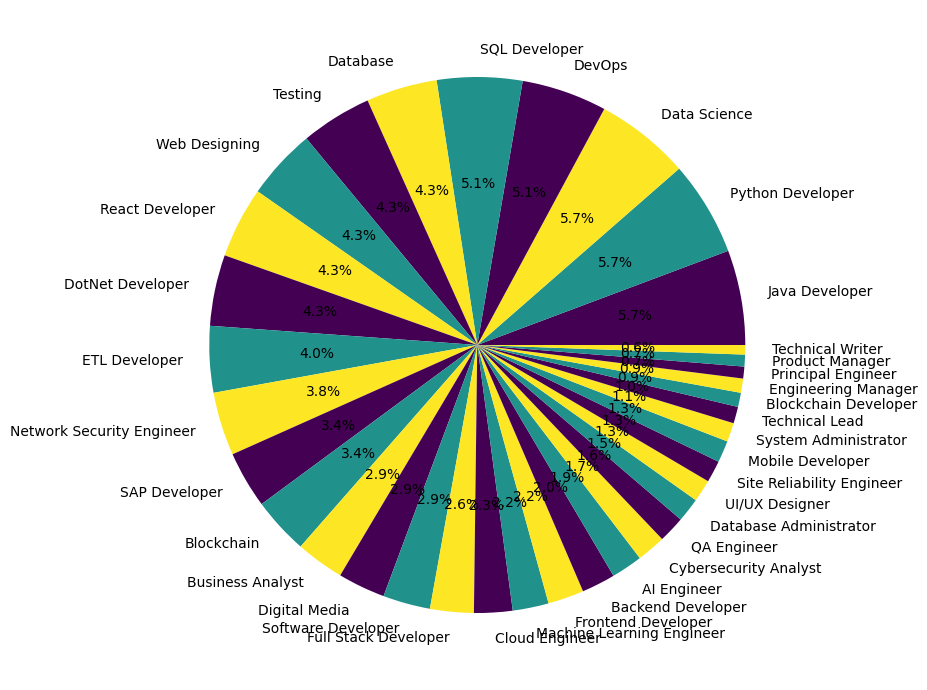

In [219]:
counts=df['category'].value_counts()
labels=df['category'].unique()
colors = plt.cm.viridis(
    np.linspace(0, 1, 3)
)
plt.figure(figsize=(12,7))
plt.pie(counts,labels=labels,autopct="%1.1f%%",colors=colors)
plt.tight_layout()
plt.show()

The pie chart provides a percentage-wise representation of resumes across job categories.

**Resume Length Distribution Across Job Categories**

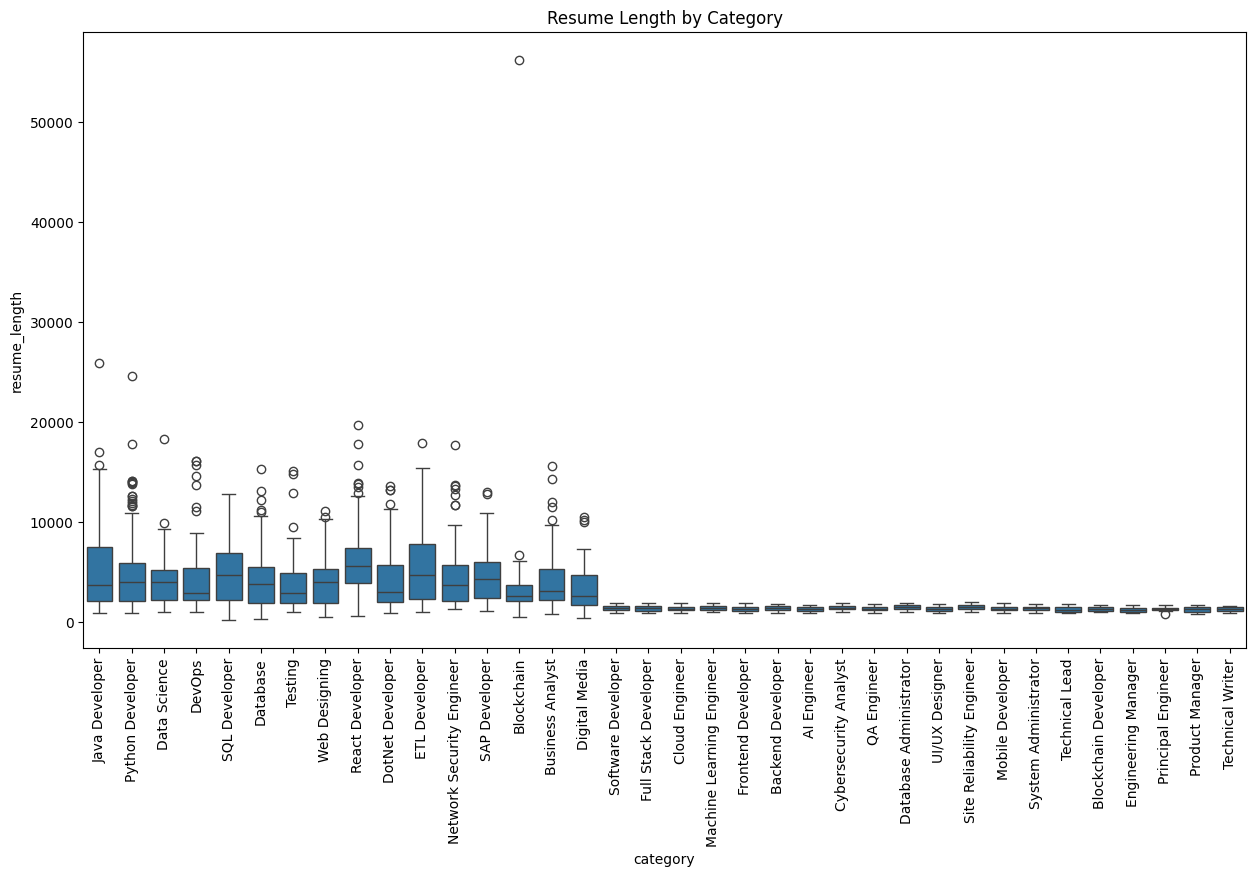

In [220]:
df['resume_length'] = df['text'].apply(len)

plt.figure(figsize=(15,8))

sns.boxplot(
    data=df,
    x='category',
    y='resume_length'
)

plt.xticks(rotation=90)
plt.title("Resume Length by Category")
plt.show()

### 4. Encoding

In [221]:
le=LabelEncoder()
df['category']=le.fit_transform(df['category'])

In [222]:
df['category'].unique()

array([17, 23,  7, 10, 27,  8, 33, 35, 25, 12, 13, 20, 26,  2,  4, 11, 29,
       16,  5, 18, 15,  1,  0,  6, 24,  9, 34, 28, 19, 30, 31,  3, 14, 21,
       22, 32])

### 5. Text Preprocessing and Cleaning

The resume text is cleaned and normalized before feature extraction. This process removes unwanted information and converts the text into a format suitable for machine learning models.

In [223]:
x=df['text']
y=df['category']

In [224]:
lem=WordNetLemmatizer()
stop_words=stopwords.words('english')

In [225]:
def cleaned_text(text):
    text=text.lower()
    text=re.sub(r'<.*?>','',text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = re.sub(r'\s+', ' ', text)
    text=word_tokenize(text)
    text=[w for w in text if w not in stop_words]
    text=[lem.lemmatize(i) for i in text]
    text=' '.join(text)
    return text
    

In [226]:
x=x.apply(cleaned_text)

**Word Cloud Visualization**

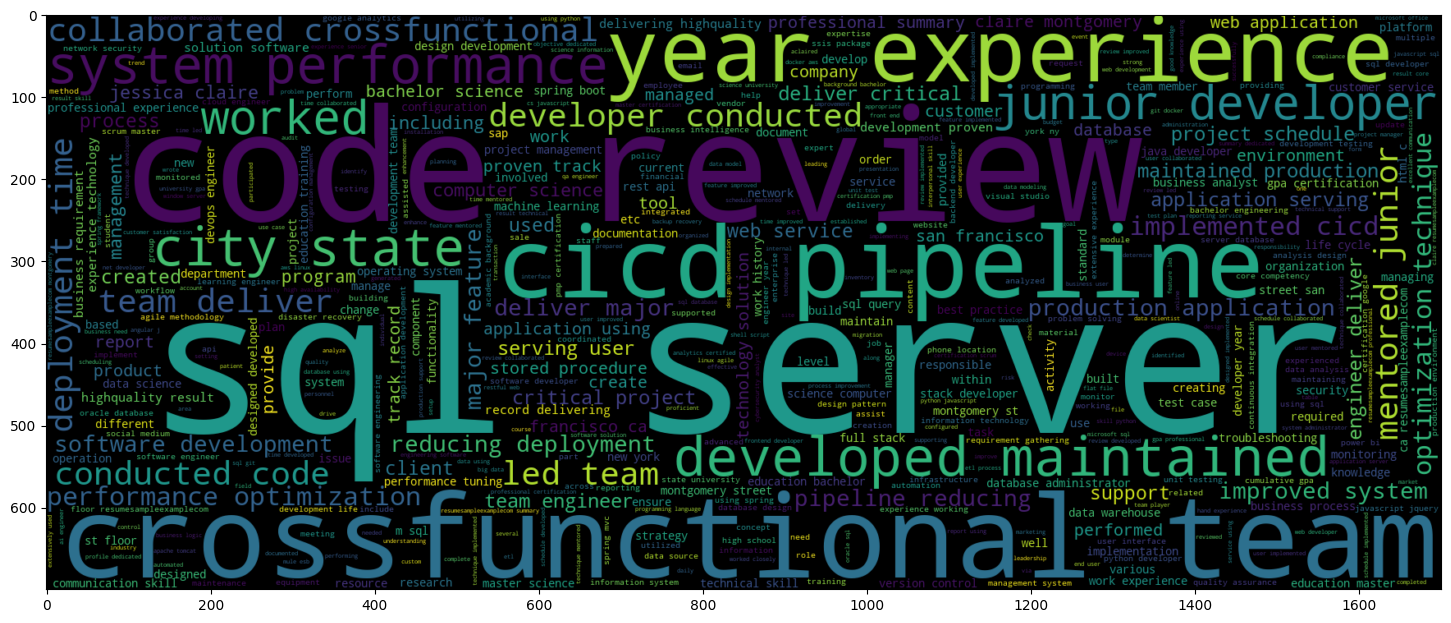

In [227]:
words=' '.join(w for w in x)
plt.figure(figsize=(18,10))
wordcloud=WordCloud(max_words=500,height=700,width=1700).generate(words)
plt.imshow(wordcloud,interpolation='bilinear')
plt.show()

The word cloud highlights the most frequently occurring words in the resume dataset. 
Words appearing larger are mentioned more often in resumes.

### 6. Feature Extraction using TF-IDF

Convert textual resume data into numerical feature vectors using TF-IDF Vectorization.

In [228]:
vect=TfidfVectorizer()
x=vect.fit_transform(x)

### 7. Train-Test Split

Split the dataset into training and testing sets for model development and evaluation.

In [229]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

### 8. Handling Imbalanced Data

RandomOverSampler balances class distribution.

In [230]:
ros = RandomOverSampler(random_state=42)

x_train, y_train = ros.fit_resample(x_train, y_train)

print(pd.Series(y_train).value_counts())

category
6     160
16    160
26    160
0     160
32    160
8     160
27    160
7     160
35    160
31    160
18    160
22    160
3     160
10    160
2     160
19    160
30    160
28    160
34    160
29    160
13    160
1     160
17    160
15    160
23    160
11    160
20    160
9     160
14    160
25    160
33    160
12    160
4     160
5     160
24    160
21    160
Name: count, dtype: int64


### 9. Model Building & Model Evaluation

Train machine learning models to classify resumes into job categories.

Evaluate the performance of each model using classification metrics.

In [231]:
model1 = LogisticRegression(
    C=2.0,
    max_iter=2000,
    random_state=42
)

model2 = MultinomialNB(
    alpha=0.1
)

model3 = LinearSVC(
   
    random_state=42,

)


In [232]:
models = {
    "Logistic Regression": model1,
    "Naive Bayes": model2,
    "Linear SVC": model3
}

results = []

for name, model in models.items():

    
    model.fit(x_train, y_train)

    
    y_pred = model.predict(x_test)

    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([
        name,
        round(accuracy * 100, 2),
        round(precision * 100, 2),
        round(recall * 100, 2),
        round(f1 * 100, 2)
    ])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
)

print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     88.29      88.49   88.29     88.03
1          Naive Bayes     84.71      85.78   84.71     84.41
2           Linear SVC     88.14      88.20   88.14     87.71


### 10. Select the Best Model

Logistic Regression with **88.29%** accuracy

In [233]:
from sklearn.metrics import classification_report
y_pred=model1.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        15
           2       0.89      0.80      0.84        10
           3       1.00      1.00      1.00         6
           4       0.94      0.97      0.95        30
           5       1.00      1.00      1.00        19
           6       1.00      1.00      1.00        13
           7       0.76      0.95      0.84        40
           8       0.90      0.60      0.72        30
           9       1.00      1.00      1.00        11
          10       0.97      0.97      0.97        36
          11       0.81      0.65      0.72        20
          12       0.79      0.82      0.81        28
          13       0.68      0.79      0.73        24
          14       1.00      1.00      1.00         6
          15       1.00      1.00      1.00        15
          16       1.00      1.00      1.00        21
          17       0.92    

**Model Evaluation Insights**

The Logistic Regression model achieved an overall accuracy of **88%**, demonstrating strong performance in resume classification.

The macro-average Precision, Recall, and F1-Score of **0.92** indicate balanced performance across different job categories.

While most categories were classified accurately, a few categories showed lower scores due to similarities in skills and keywords among related job roles.

Overall, the results confirm that TF-IDF, Random Oversampling, and Logistic Regression provide an effective solution for automated resume screening and classification.

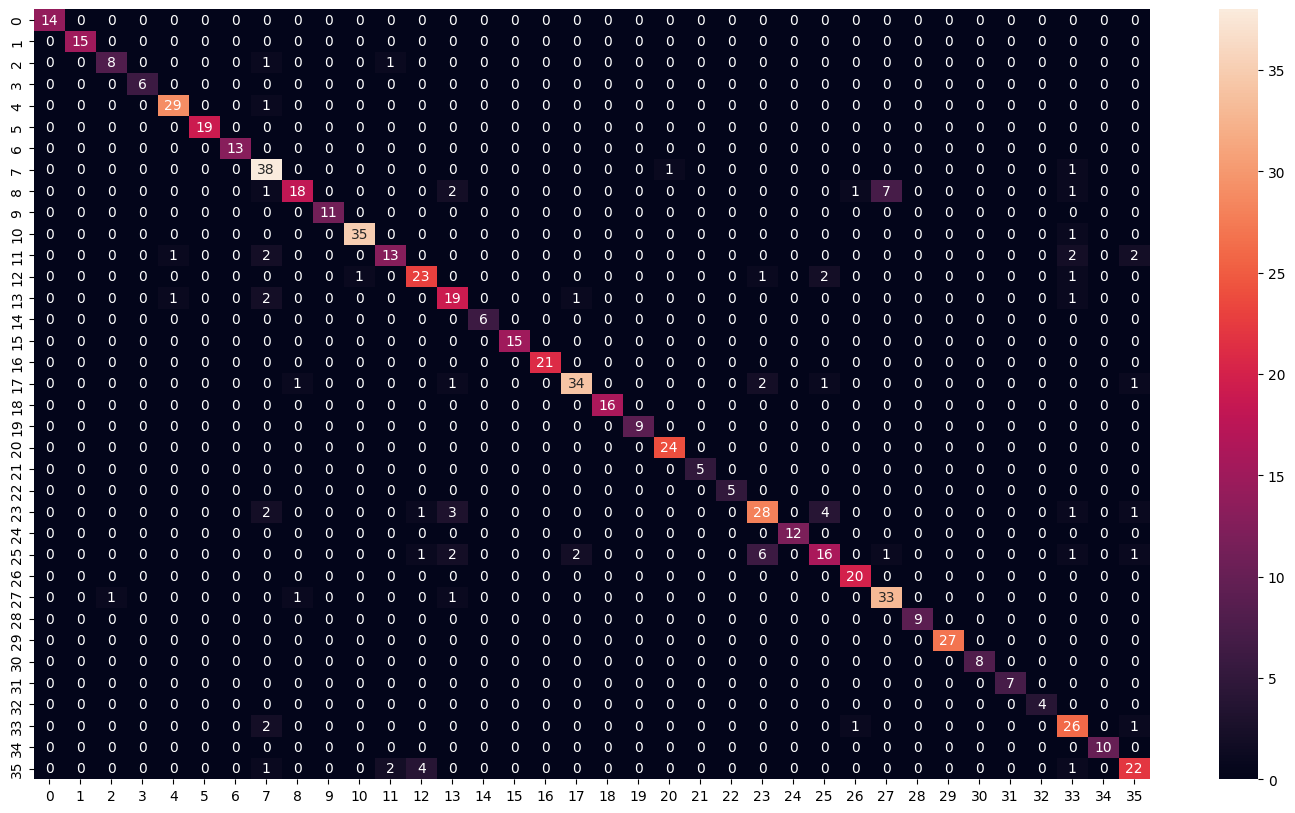

In [234]:
plt.figure(figsize=(18,10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

**Confusion Matrix Insights**

- Most predictions lie on the main diagonal, indicating correct classifications.
- Very few off-diagonal errors were observed.
- The model effectively differentiates between multiple resume categories.
- Misclassifications mainly occur between categories with overlapping skills.
- Results confirm the model's strong performance and reliability.

### 11. Save the Trained Model

Store the trained model and TF-IDF vectorizer for future predictions.

In [235]:
import pickle
# pickle.dump(x,open('resume_text.pkl','wb'))
pickle.dump(vect,open('vect.pkl','wb'))
pickle.dump(model1,open('model.pkl','wb'))
pickle.dump(le, open('label_encoder.pkl', 'wb'))

### 12. Resume Classification Prediction

In [236]:
def pred(input_resume):
    cleaned_resume=cleaned_text(input_resume)

    vectorized_resume=vect.transform([cleaned_resume])

    predicted_category=model1.predict(vectorized_resume)

    predicted_category_name=le.inverse_transform(predicted_category)

    return predicted_category_name[0]

In [237]:
My_resume="""SANA K
sanajaseel0@gmail.com 7902618145 Kannur, Kerala www.linkedin.com/in/sana-k-415015195
PROFILE
Java Application Support Engineer with 2+ years of experience at
Infosys, specializing in application support, system operations,
and backend development. Skilled in Java, Spring Boot, SQL,
REST APIs, and incident management with strong expertise in
troubleshooting and production support. Currently expanding
into Data Science, Machine Learning, Deep Learning, and NLP
using Python and related tools
SKILLS
Programming & Tools:
Python, NumPy, Pandas, SQL, Java, Spring Boot, REST APIs.
Data Science & Analytics:
Data Cleaning, EDA, Data Visualization (Matplotlib)
Machine Learning:
Scikit-learn, Regression, Classification, Clustering, Model
Evaluation, Feature Engineering .
Deep Learning & NLP:
TensorFlow/Keras (Basics), Neural Networks, CNN, RNN,
Tokenization, Stopwords Removal, TF-IDF, Bag of Words
Databases & IT Tools:
SQL (CRUD, Joins), Jupyter Notebook, Google Colab, Git/GitHub
(Basic), ServiceNow Ticketing System
IT Support:
Application Support, Incident Management, Batch Monitoring, Issue
Resolution
Computer Vision
OpenCV (Image Processing, Thresholding, Resizing, Cropping, Face
Detection Basics)
Soft Skills
Problem Solving, Analytical Thinking, Attention to Detail, Team
Collaboration, Communication, Process Improvement
PROFESSIONAL EXPERIENCE
Systems Engineer
Infosys Ltd
12/2021 – 02/2024 | Bengaluru, India
•Successfully supported and maintained applications
at Infosys, ensuring system reliability.
•Designed, enhanced, and troubleshot applications using
Java, Spring Boot, and SQL.
•Handled incident management via ServiceNow and
coordinated with cross-functional teams for quick
resolution.
•Managed Production Support operations by actively
monitoring and executing Manual Recovery Processes
for failed batch jobs, resulting in minimized operational
downtime.
•Collaborated with business users to gather
requirements, provide technical support, and deliver
system enhancements.
•Implemented Process Improvement techniques for
recurring incidents, collaborating with business users to
gather requirements and deliver stable system
enhancements.
EDUCATION
Electrical and Elecronics Engineering
KTU University Kerala
2017 – 2021
CERTIFICATES
Infosys Certified spring Associate
Infosys Certified Java SE8 Developer
LANGUAGES
English
Malayalam"""

pred(My_resume)

'Java Developer'

### 13. Model Deployment Using Streamlit

Deploy the trained machine learning model as a web application.

**Deployment Process**
1. Save the trained model using Pickle.
2. Save the TF-IDF vectorizer.
3. Create a Streamlit application (app.py).
4. Load the saved model and vectorizer.
5. Accept resume input from users.
6. Predict and display the job category.

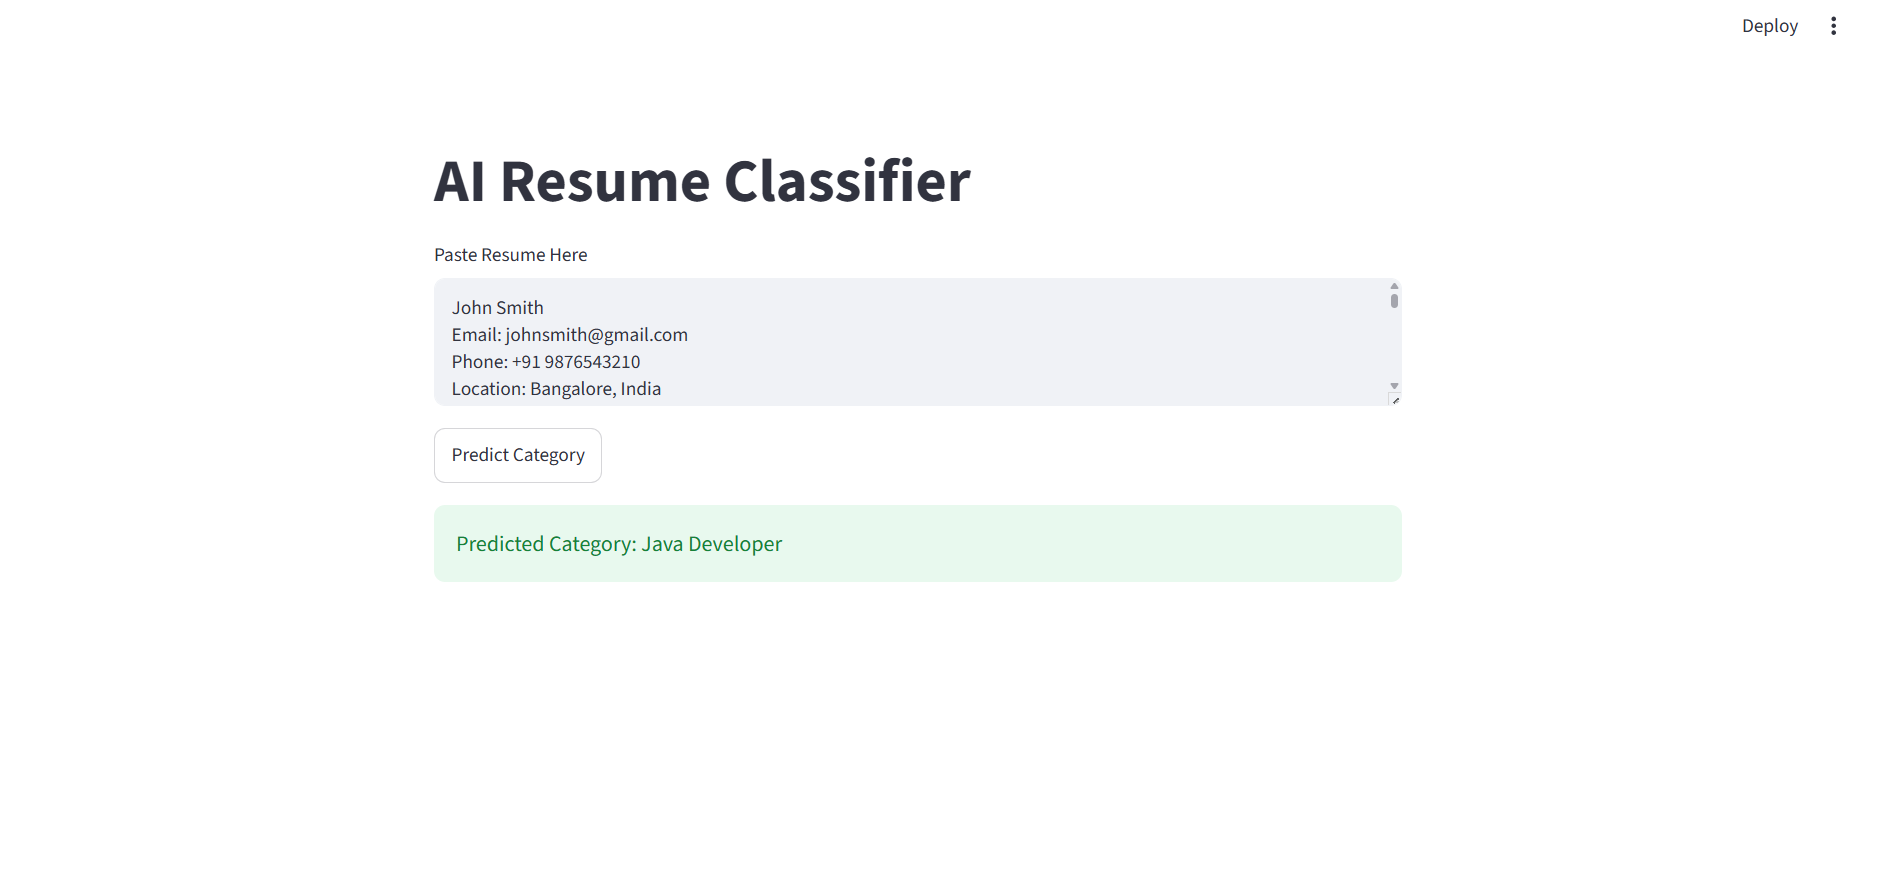

### 14. Results and Discussion

- Successfully classified resumes into multiple job categories.
- NLP preprocessing improved text quality.
- TF-IDF effectively converted text into machine-readable format.
- Machine Learning models achieved high classification accuracy.
- Streamlit deployment enabled real-time predictions through a web interface.

### 15. Conclusion

The AI-Based Resume Screening and Classification System automates the recruitment process by classifying resumes into appropriate job categories. By leveraging NLP and Machine Learning techniques, the system reduces manual screening effort and improves recruitment efficiency.
